Nome: Letícia Lopes Mendes da Silva

RA: 184423

Curso: Eng. de Computação

# Ex05 - Classificação de imagens usando rede neural convolucional (CNN)

O objetivo principal deste notebook é ilustrar e praticar o uso de redes neurais convolucionais (CNNs) para tarefas de classificação de imagens. Em relação às redes neurais convencionais, as CNNs geralmente apresentam a vantagem de possuir menos parâmetros a serem aprendidos. Além disso, as CNNs são particularmente adequadas para trabalhar com imagens devido à sua arquitetura projetada para lidar com dados espaciais de forma eficiente.

Tomaremos como base a biblioteca PyTorch, que segue uma abordagem de programação orientada a objetos. Além dela, recomendamos o uso de outras bibliotecas relacionadas (como o PyTorch Lightning) que auxiliam e simplificam etapas do framework. Note que algumas destas bibliotecas podem não estar disponíveis por padrão no Colab ou sua máquina, sendo necessária sua instalação (como exemplificado na próxima célula de código).

Para mais informações sobre redes convolucionais, exemplos e boas práticas, recomendamos os materiais de apoio às aulas 5 e 6 disponibilizados no classroom. Lá você vai encontrar um tutorial teórico sobre CNN, além de tutoriais práticos disponibilizados no GitHub, vídeos e links de apoio. Em especial, o tutorial prático de classificação com CNN ([link](https://colab.research.google.com/drive/1uXLYbWwHT8cChAYmexV6QNUi5eI4ITod?usp=sharing)) pode ser de grande ajuda.

**Atenção!** Não se esqueça de utilizar a GPU do Colab (clique em "Ambiente de execução" e "Alterar o tipo de ambiente de execução", selecione a GPU).

In [ ]:
# Instalando bibliotecas
!pip install pytorch-lightning torchinfo torchmetrics torch-summary torchmetrics medmnist tensorboard

In [ ]:
# Importando as bibliotecas que serão utilizadas
import multiprocessing as mp
import os
import random
import sys
from glob import glob

import matplotlib.pyplot as plt
import numpy as np
import pytorch_lightning as pl
import torch
import torchinfo
from pytorch_lightning.callbacks import ModelCheckpoint
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from torch import nn
from torch.optim import AdamW
from torch.utils.data import DataLoader
from torchmetrics import Accuracy
from torchsummary import summary
from torchvision import datasets, models
from torchvision import transforms
from torchvision.utils import make_grid

%load_ext tensorboard

In [3]:
torch.set_float32_matmul_precision('medium')

## Parte 1 - Exemplo de classificação com o MNIST

Exemplificaremos algumas das etapas do framework de classificação com CNN utilizando o conjunto de dados MNIST (Modified National Institute of Standards and Technology database), um grande conjunto de dados de dígitos manuscritos comumente usado na área de aprendizado de máquina. Ele consiste de 60.000 imagens de treinamento e 10.000 images de teste (que, no nosso exemplo, serão utilizadas para validação). As imagens do conjunto são de 28x28 pixels. Uma descrição completa do conjunto de dados pode ser encontrada [aqui](https://en.wikipedia.org/wiki/MNIST_database).

### Leitura dos dados

Idealmente, códigos para processar amostras de dados devem estar desacoplados do código do treinamento do modelo, facilitando sua legibilidade e modularidade. O PyTorch fornece duas primitivas de dados ([torch.utils.data.DataLoader](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) e [torch.utils.data.Dataset](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset)) que facilitam a leitura, processamento e organização dos dados para entrada no modelo. Mais informações sobre Datasets e DataLoaders podem ser encontradas [aqui](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html) e [aqui](https://blog.paperspace.com/dataloaders-abstractions-pytorch/).

In [2]:
# Carregando os dados utilizando torchvision.datasets e convertendo as imagens para tensores
training_data = datasets.MNIST(
    root="data_mnist",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)
val_data = datasets.MNIST(
    root="data_mnist",
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

print(training_data)
print()
print(val_data)
print()
print("*Note que, apesar de identificado como teste, utilizaremos o segundo conjunto de dados para validação!")

Dataset MNIST
    Number of datapoints: 60000
    Root location: data_mnist
    Split: Train
    StandardTransform
Transform: ToTensor()

Dataset MNIST
    Number of datapoints: 10000
    Root location: data_mnist
    Split: Test
    StandardTransform
Transform: ToTensor()

*Note que, apesar de identificado como teste, utilizaremos o segundo conjunto de dados para validação!


**É sempre importante checar e visualizar os dados a cada etapa do framework de classificação, garantindo que eles estão de acordo com o esperado e evitando a propagação de erros.**

2
<class 'torch.Tensor'> <class 'int'>
Shape da imagem: torch.Size([1, 28, 28])
Label: 0
Maior valor de intensidade da imagem: tensor(1.)
Menor valor de intensidade da imagem: tensor(0.)


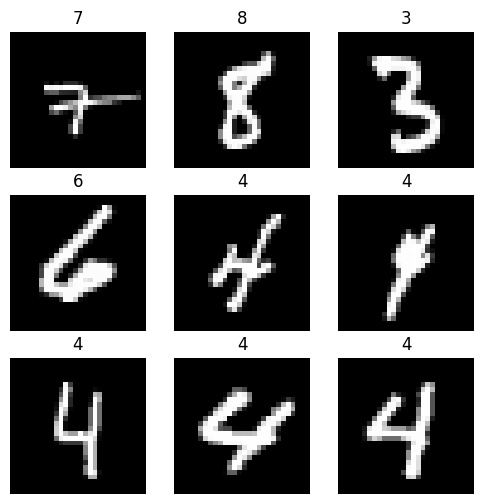

In [5]:
# Checando informações de uma amostra de treinamento
training_example = random.choice(training_data)
print(len(training_example))
print(type(training_example[0]), type(training_example[1]))
print('Shape da imagem:', training_example[0].shape)
print('Label:', training_example[1])
print('Maior valor de intensidade da imagem:', torch.max(training_example[0]))
print('Menor valor de intensidade da imagem:', torch.min(training_example[0]))

# Visualizando algumas imagens e labels do conjunto de treinamento
figure = plt.figure(figsize=(6, 6))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    img, label = random.choice(training_data)
    plt.subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1)
plt.show()

2
<class 'torch.Tensor'> <class 'int'>
Shape da imagem: torch.Size([1, 28, 28])
Label: 2
Maior valor de intensidade da imagem: tensor(1.)
Menor valor de intensidade da imagem: tensor(0.)


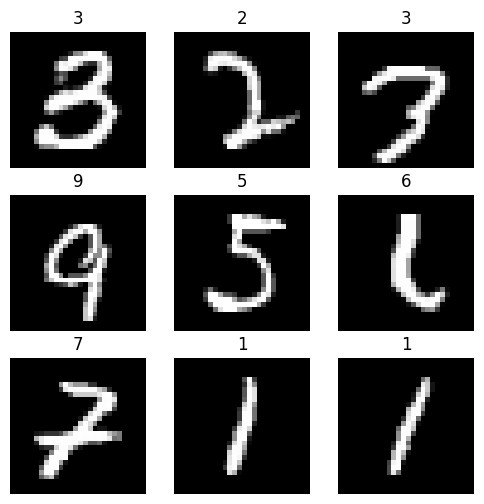

In [6]:
# Checando informações de uma amostra de validação
val_example = random.choice(val_data)
print(len(val_example))
print(type(val_example[0]), type(val_example[1]))
print('Shape da imagem:', val_example[0].shape)
print('Label:', val_example[1])
print('Maior valor de intensidade da imagem:', torch.max(val_example[0]))
print('Menor valor de intensidade da imagem:', torch.min(val_example[0]))

# Visualizando algumas imagens e labels do conjunto de validação
figure = plt.figure(figsize=(6, 6))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    img, label = random.choice(val_data)
    plt.subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1)
plt.show()

### Exercício 1.1

Explique o processamento aplicado pela classe torchvision.transforms.ToTensor às imagens do conjunto. Explique também porque foi necessário utilizar o .squeeze() para visualizar as imagens e qual a sua função.

**RESPOSTA:**

A classe `torchvision.transforms.ToTensor` converte a imagem de entrada, que normalmente está em formato PIL ou `numpy.ndarray`, para um tensor do PyTorch. Nesse processo, os valores dos pixels são convertidos para ponto flutuante e reescalados para o intervalo `[0, 1]`, além de reorganizar as dimensões para o formato `(C, H, W)`, em que `C` é o número de canais, `H` a altura e `W` a largura da imagem.

No caso do MNIST, as imagens são em escala de cinza, então o tensor fica com formato `(1, 28, 28)`. Segundo a documentação do matplotlib sobre a função [matplotlib.pyplot.imshow](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html), a função deve receber uma imagem X com a seguinte especificação:

```shell
X : array-like or PIL image. The image data. Supported array shapes are:

    - (M, N): an image with scalar data. The values are mapped to
        colors using normalization and a colormap. See parameters
        *norm*, *cmap*, *vmin*, *vmax*.
    - (M, N, 3): an image with RGB values (0-1 float or 0-255 int).
    - (M, N, 4): an image with RGBA values (0-1 float or 0-255 int),
        i.e. including transparency.

    The first two dimensions (M, N) define the rows and columns of
    the image.
```

Por isso, usamos `.squeeze()` para remover a dimensão unitária do canal e obter o formato `(28, 28)`, que pode ser exibido com `plt.imshow`. Essa justificativa vale para o MNIST pois ele contém imagens em preto e branco. Mas uma forma mais abrangente é usar `.permute(1, 2, 0)`, que reorganiza os eixos para o formato esperado, o que é útil quando a imagem tem múltiplos canais, como em RGB. Assim, o tensor `(1, 28, 28)` se tornaria `(28, 28, 1)`, e o matplotlib entenderia que se trata de uma imagem escalar.

### Hiperparâmetros

É interessante utilizar um dicionário de hiperparâmetros para organizar o código, evitar "números mágicos" e registrar as configurações de cada experimento realizado.

In [7]:
hparams = {"experiment_name": "Test_ResNet_1",  # experiment name identifies the run for later
           "max_epochs": 10,  # number of epochs to train
           "batch_size": 100,  # size of batch
           "nworkers": 0 if sys.platform.startswith("win") else mp.cpu_count(),  # number of workers to use in parallel loading
           "nout": 10,  # number of classes
           "nin": 1,  # number of channels of the input image
           "lr": 1e-4,  # learning rate
           "wd": 1e-5,  # weight decay for optimizer
           "cpu": False,  # forces using the CPU
           }

for k, v in hparams.items():
    print(f"{k}: {v}")

experiment_name: Test_ResNet_1
max_epochs: 10
batch_size: 100
nworkers: 16
nout: 10
nin: 1
lr: 0.0001
wd: 1e-05
cpu: False


### Data Module

A classe [pytorch_lightning.LightningDataModule](https://lightning.ai/docs/pytorch/stable/data/datamodule.html) pode ser utilizada para organizar os DataLoaders e os dados.

In [8]:
class MNISTDataModule(pl.LightningDataModule):
    def __init__(self, hparams):
        super().__init__()
        self.save_hyperparameters(hparams)

    def setup(self, stage=None):
        self.train = training_data
        self.val = val_data

    '''
    Dataloaders optimize data loading and automatically prepare batches
    '''
    def train_dataloader(self):
        return DataLoader(self.train, 
                            batch_size=self.hparams.batch_size, 
                            num_workers=self.hparams.nworkers, 
                            shuffle=True,
                            persistent_workers=True,
                            pin_memory=True)

    def val_dataloader(self):
        return DataLoader(self.val, 
                          batch_size=self.hparams.batch_size, 
                          num_workers=self.hparams.nworkers, 
                          shuffle=False,
                          persistent_workers=True,
                          pin_memory=True)

**Novamente, checamos os dados obtidos através do DataModule.**

Shape do batch: torch.Size([100, 1, 28, 28])


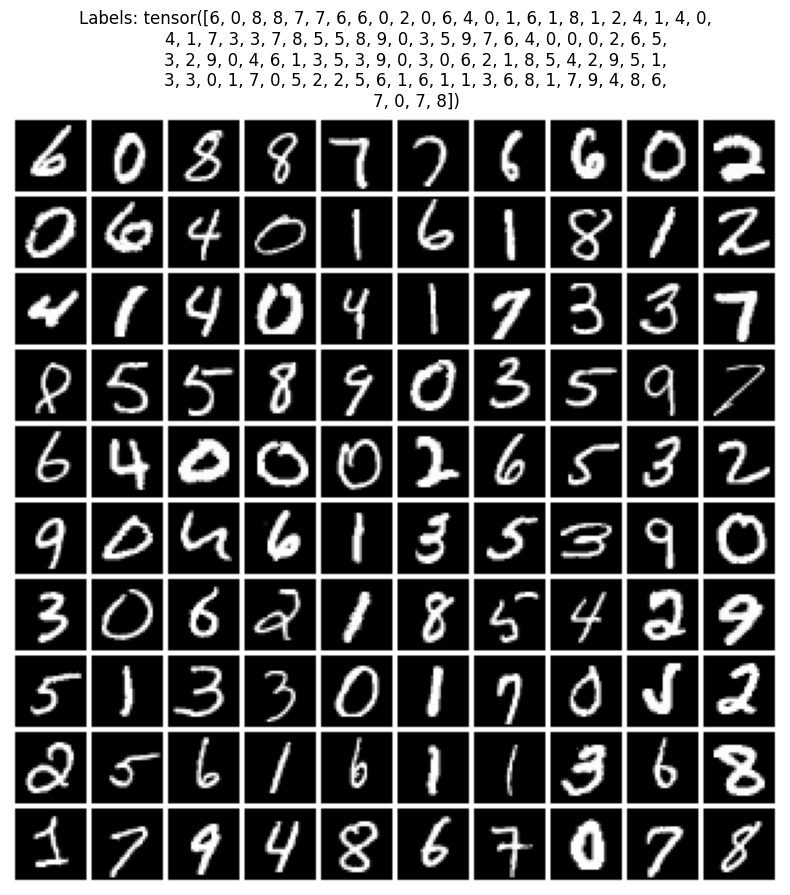

In [9]:
# DEBUG DATA MODULE
data_module = MNISTDataModule(hparams)
data_module.setup()

check_dataloader = data_module.train_dataloader()
img_batch, label_batch = next(iter(check_dataloader))
print("Shape do batch:", img_batch.shape)

img_grid = make_grid(img_batch, nrow=10, pad_value=1)
fig = plt.figure(figsize=(10,10))
plt.imshow(img_grid.permute(1, 2, 0).numpy())
plt.title(f'Labels: {label_batch}')
plt.axis('off')
plt.show()

### Definindo a CNN

No código abaixo, é criado um modelo baseado na [Resnet-18](https://pytorch.org/vision/master/models/generated/torchvision.models.resnet18.html). O mesmo será treinado **sem transfer learning** e com uma inicialização randômica dos pesos. Visualizamos também todas as camadas (layers) que compõem o modelo e seus parâmetros.

In [10]:
cnn_model = models.resnet18(weights=None)
print(cnn_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [11]:
cnn_model.conv1 = nn.Conv2d(hparams['nin'], 64, kernel_size=7, stride=2, padding=3, bias=False)
num_ftrs = cnn_model.fc.in_features
cnn_model.fc = nn.Linear(num_ftrs, hparams['nout'])
print(cnn_model)

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### Exercício 1.2

Para que serve cada camada da rede? Por que foi necessário modificar ligeiramente a rede (célula anterior) e que modificações foram realizadas?

**RESPOSTA:**

De modo geral, uma camada é uma transformação aplicada aos dados de entrada da rede. No modelo apresentado, cada componente como conv1, bn1, relu representa uma camada específica:

- `Conv2d` é uma camada convolucional, que extrai características da imagem, como bordas, texturas e outros padrões, por meio de filtros aprendíveis.
- `BatchNorm2d` aplica normalização para ajudar na estabilidade e na velocidade do treinamento.
- `ReLu` é uma função de ativação que introduz não linearidade, permitindo que a rede aprenda representações mais complexas.
- `MaxPool2d` é uma camada de pooling que reduz a dimensão espacial, preservando as informações mais relevantes.
- Os blocos residuais (layer1 a layer4) são conjuntos de camadas que aprendem representações cada vez mais abstratas dos dados.
- `AdaptiveAvgPool2d` é uma camada de pooling global, que reduz cada mapa de características em um único valor por canal
- Por fim, `Linear` é uma camada linear totalmente conectada, que transforma essas features finais no resultado da classificação.

Foi necessário adaptar a ResNet-18 pois a versão original foi criada para imagens RGB de 3 canais e para classificação em 1000 classes do ImageNet. Como o MNIST possui imagens em escala de cinza, com apenas 1 canal, a camada `conv1` precisou ser modificada para aceitar `nin = 1`. Além disso, a camada final `fc` foi trocada para produzir `nout = 10` saídas, correspondendo às 10 classes dos dígitos.

### Resumo do modelo

In [12]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
cnn_model.to(device)
summary(cnn_model, (1, 28, 28));

cuda:0
Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 64, 14, 14]          3,136
├─BatchNorm2d: 1-2                       [-1, 64, 14, 14]          128
├─ReLU: 1-3                              [-1, 64, 14, 14]          --
├─MaxPool2d: 1-4                         [-1, 64, 7, 7]            --
├─Sequential: 1-5                        [-1, 64, 7, 7]            --
|    └─BasicBlock: 2-1                   [-1, 64, 7, 7]            --
|    |    └─Conv2d: 3-1                  [-1, 64, 7, 7]            36,864
|    |    └─BatchNorm2d: 3-2             [-1, 64, 7, 7]            128
|    |    └─ReLU: 3-3                    [-1, 64, 7, 7]            --
|    |    └─Conv2d: 3-4                  [-1, 64, 7, 7]            36,864
|    |    └─BatchNorm2d: 3-5             [-1, 64, 7, 7]            128
|    |    └─ReLU: 3-6                    [-1, 64, 7, 7]            --
|    └─BasicBlock: 2-2                   [-1, 64, 7, 7]         

### Exercício 1.3

Tente entender as dimensões da saída de cada camada da rede. Por exemplo, por que as três primeiras camadas possuem saídas com dimensões `(-1, 64, 14, 14)` e a quarta camada tem saída com dimensões `(-1, 64, 7, 7)`?

E quanto aos parâmetros a serem aprendidos, você consegue explicar como eles são calculados?

**RESPOSTA:**

As saídas das camadas seguem o formato:

```math
(\text{batch}, \text{canais}, \text{altura}, \text{largura}) = (B, C, H, W)
```

O valor `-1` representa o tamanho do batch, que pode variar de acordo com o `DataLoader`.

A mudança de dimensão acontece principalmente nas camadas convolucionais e de pooling. De acordo com a documentação do pytorch ([torch.nn.Conv2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.conv.Conv2d.html) e [torch.nn.MaxPool2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.pooling.MaxPool2d.html)), as dimensões $H_{out}$ e $W_{out}$ de saída são dadas por:

```math
\text{out} = \left\lfloor\frac{\text{in} + 2 \times \text{padding} - \text{dilation} \times (\text{kernel\_size} - 1) - 1}{\text{stride}} + 1\right\rfloor
```

Por padrão, `dilation = 1`.

No caso do MNIST, a entrada tem forma `(1, 28, 28)`:

- `conv1` usa $\text{kernel} = 7\times7$, $\text{stride} = 2$ e $\text{padding} = 3$, então reduz a resolução de $28\times28$ para $14\times14$ e produz 64 mapas: saída `(-1, 64, 14, 14)`.

```math
\text{out} = \left\lfloor\frac{28 + 2 \times 3 - (7 - 1) - 1}{2} + 1\right\rfloor = 14
```

- `bn1` e `relu` não alteram as dimensões, então a forma permanece `(-1, 64, 14, 14)`.
- `maxpool` usa $\text{kernel} = 3\times3$, $\text{stride} = 2$ e $\text{padding} = 1$, reduzindo de $14\times14$ para $7\times7$: saída `(-1, 64, 7, 7)`.

```math
\text{out} = \left\lfloor\frac{14 + 2 \times 1 - (3 - 1) - 1}{2} + 1\right\rfloor = 7
```

Reduções como essa acontecem ao longo da rede sempre que há convoluções com `stride > 1` ou operações de pooling.

---

Os parâmetros aprendíveis de uma rede neural correspondem aos *weights* (pesos) e *biases*, que são ajustados durante o treinamento por meio de algoritmos de otimização com base no gradiente de uma função de perda (*loss*). Esse gradiente é calculado via *backpropagation*, que aplica a regra da cadeia para propagar o erro da saída da rede até as camadas iniciais. A partir desses gradientes, algoritmos de otimização (como SGD, Adam ou AdamW) atualizam os parâmetros iterativamente a fim de minimizar a *loss*.

A forma de calcular os parâmetros depende da camada.

- **Camadas convolucionais ([torch.nn.Conv2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.conv.Conv2d.html))**:

Como já vimos, nas camadas convolucionais, cada saída é obtida pela aplicação de filtros (kernels) sobre os canais de entrada. Cada filtro possui um conjunto de pesos que são aprendidos durante o treinamento. Esses pesos formam um tensor de dimensão:

```math
(C_{out}, \frac{C_{in}}{groups}, \text{kernel\_size}, \text{kernel\_size})
```

Se houver bias, ele adiciona mais $C_{out}$ parâmetros. Nas convoluções da ResNet, usa-se `groups = 1` e `bias = False`, pois o `BatchNorm2d` já introduz um deslocamento aprendível depois da convolução. Assim, o número de parâmetros de cada convolução é:

```math
C_{out} \times C_{in} \times \text{kernel\_size} \times \text{kernel\_size}
```

- **Camadas de normalização ([torch.nn.BatchNorm2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.BatchNorm2d.html#torch.nn.BatchNorm2d))**:

Nas camadas de normalização, são aprendidos dois parâmetros por canal de entrada: um fator de escala ($\gamma$) e um de deslocamento ($\beta$). Assim, cada camada possui $2 \times C_{in}$ parâmetros aprendíveis.

- **Camadas lineares ([torch.nn.Linear](https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.linear.Linear.html))**:

Nas camadas lineares, os parâmetros correspondem a uma matriz de pesos `W` e um vetor de bias `b`. Se a camada tiver `in_features = Nin` e `out_features = Nout`, então o total de parâmetros é:

```math
N_{out} \times N_{in} + N_{out}
```

- **Outras camadas:**
ReLU, pooling e outras operações não têm parâmetros ajustáveis, pois realizam apenas transformações fixas sobre os dados.

### Lightning Module

Aqui definimos o comportamento durante o treinamento, ou seja, o que acontece com um lote retornado pelo DataLoader.

In [13]:
class TrainMNIST(pl.LightningModule):
    def __init__(self, hparams):
        super().__init__()

        self.save_hyperparameters(hparams)
        self.model = cnn_model
        self.loss = nn.CrossEntropyLoss()
        self.accuracy = Accuracy(task="multiclass", num_classes=self.hparams.nout)

        torchinfo.summary(self.model)

    def forward(self, x):
        return self.model(x).softmax(dim=-1)

    def classification_step(self, mode, batch):
        x, y = batch
        y_hat = self.forward(x)
        loss = self.loss(y_hat, y)

        if mode == "train":
            self.log("loss", loss, on_epoch=True, on_step=True)
            return loss
        elif mode == "val":
            _, preds = torch.max(y_hat, 1)
            self.accuracy(preds, y)
            self.log("val_loss", loss, on_epoch=True, on_step=False, prog_bar=True)
            self.log("val_acc", self.accuracy, on_epoch=True, on_step=False, prog_bar=True)

    def training_step(self, train_batch, batch_idx):
        return self.classification_step("train", train_batch)

    def validation_step(self, val_batch, batch_idx):
        self.classification_step("val", val_batch)

    def configure_optimizers(self):
        optimizer = AdamW(self.model.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.wd)

        return optimizer

### Treinando a CNN

In [ ]:
debug = False  # Turn this True to test the code with a quick run

# Initialization
model = TrainMNIST(hparams)
data = MNISTDataModule(hparams)

# The PL trainer can run various callbacks during training. Here we only use the
# callback that saves the weights of the trained network.
os.makedirs("logs", exist_ok=True)
checkpoint_callback = [ModelCheckpoint(dirpath="logs",  # path to save checkpoint
                                       filename=hparams["experiment_name"] + "-{epoch}-{val_acc:.2f}",
                                       monitor="val_acc",
                                       mode="max")]

trainer = pl.Trainer(max_epochs=hparams["max_epochs"], #devices=1, accelerator="gpu",
                     fast_dev_run=debug,
                     callbacks=checkpoint_callback,
                     log_every_n_steps=1
                     )

print("Hyperparameters:\n")
for k, v in hparams.items():
    print(f'{k}: {v}')

trainer.fit(model, data)

### Visualizando os logs de treinamento

Por padrão, o Pytorch Lightning registra os resultados do treinamento usando o TensorBoard. Você pode configurar muitos outros registradores (https://pytorch-lightning.readthedocs.io/en/stable/extensions/logging.html), recomendamos verificar o Neptune ou o MLFlow. Utilize esses registradores para comparar experimentos!

Abaixo é possível verificar os resultados do treinamento realizado previamente (disponibilizado no diretório **Dados/Ex05/saved_lightning_logs**).

In [ ]:
%tensorboard --logdir lightning_logs

### Análise dos resultados

Após o treinamento da rede, é importante checar os resultados de validação, visualizando algumas saídas da rede e obtendo métricas de classificação. Abaixo exemplificamos a visualização da matriz de confusão.

In [16]:
# WARNING: This will load a random checkpoint from the logs folder, if you want an specific one change it!
# baseline_model = random.choice(glob("logs/*.ckpt"))

baseline_model = random.choice(glob("logs/Test_ResNet_1*.ckpt"))
print(f"Using model {baseline_model}")

# Load trained model
model = TrainMNIST.load_from_checkpoint(baseline_model).eval().cuda()

# Initialize validation data
data = MNISTDataModule(hparams)
data.setup()
data.hparams.batch_size = 1
val_data = data.val_dataloader()

def collect_2d_results(data, model):
    y_trues = []
    y_labels = []
    for (img, label) in data:
        with torch.no_grad():
            out = model(img.cuda()).argmax(dim=-1).item()
        
        label = label.numpy()
        y_trues.append(label)
        y_labels.append(out)

    return y_trues, y_labels

y_trues_val, y_labels_val = collect_2d_results(val_data, model)

Using model logs/Test_ResNet_1-epoch=5-val_acc=0.99.ckpt


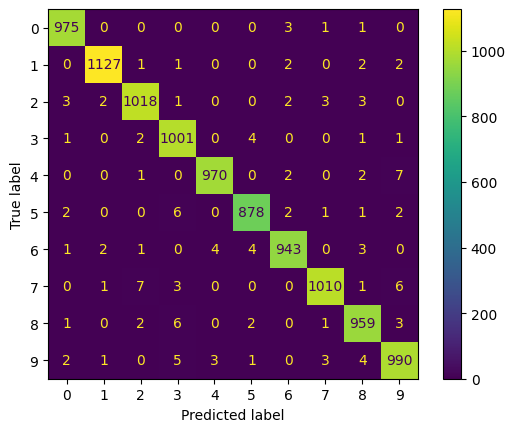

In [17]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_trues_val, y_labels_val, labels=np.arange(10)),
                                display_labels=np.arange(10))
fig = disp.plot(ax=None).figure_
plt.show()

Por fim, o modelo final seria avaliado em um conjunto de teste (que não está disponível no exemplo apresentado). **Vale ressaltar que o conjunto de teste não deve ser utilizado para refinar o modelo! Ele deve ser utilizado apenas para uma avaliação final do modelo.**